# The Larry Portfolio — a quantitative teardown 🔬
### The return-match HAC/bootstrap · the Sharpe-difference bootstrap · the equity-risk arithmetic · a justified 2007 era split on the premium's decay · a CAPM-neutral synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Decayed%3F: Mixed](https://img.shields.io/badge/Decayed%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Swedroe's construction — 30% small-cap value / 70% bonds vs a 60/40 — is a clean, falsifiable claim with an academic anchor (Banz 1981; Fama-French 1992/1993) and an obvious mechanism: if small-value's expected return exceeds what its market beta implies by enough, a smaller weighted sleeve of it can match a larger weighted sleeve of the plain market. The job here is to measure whether that premium showed up, and if not, exactly where the pitch breaks.

> ⚠️ **Data note.** IJS/IEF/SPY/SHY daily total-return closes (2002-07-30 → 2026-06-30), yfinance, cached, joint window bound by IEF/SHY's shared inception. No survivorship (broad, still-listed ETFs). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (joint fingerprint `8940a2d59087`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from larry_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    RETS = st.to_returns(PX)
else:
    PX = RETS = None
print("real cache present:", HAVE_REAL, "| tape rows:", (0 if PX is None else len(PX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-07-30', 'end': '2026-06-30', 'n': 6018, 'larry_cagr': 5.99, 'larry_vol': 7.1, 'larry_sharpe': 0.609, 'larry_dd': -20.8, 'sixty_cagr': 8.65, 'sixty_vol': 10.2, 'sixty_sharpe': 0.659, 'sixty_dd': -29.8, 'spy_cagr': 11.24, 'spy_vol': 18.8, 'spy_sharpe': 0.544, 'spy_dd': -55.2, 'ijs_cagr': 10.18, 'ijs_vol': 24.0, 'ijs_sharpe': 0.436, 'ijs_dd': -60.1, 'ief_cagr': 3.6, 'ief_vol': 6.8, 'ief_sharpe': 0.315, 'ief_dd': -23.9, 'cagr_gap': -2.66, 'mean_diff_pt': -2.75, 'mean_diff_lo': -4.92, 'mean_diff_hi': -0.52, 'hac_t_ret': -2.29, 'sharpe_gap': -0.05, 'sharpe_lo': -0.292, 'sharpe_hi': 0.187, 'larry_win_frac': 32, 'corr_larry_spy': 0.57, 'corr_sixty_spy': 0.96, 'prem_whole': 0.15, 'prem_whole_t': 0.06, 'prem_whole_n': 6017, 'prem_early': 5.08, 'prem_early_n': 1114, 'prem_early_t': 1.2, 'prem_late': -0.97, 'prem_late_n': 4903, 'prem_late_t': -0.35, 'prem_diff_t': -1.11, 'split_year': 2007, 'syn_null_mean': 0.01, 'syn_null_sd': 1.06, 'syn_null_fire': 1, 'syn_null_cagr_gap': -1.23, 'syn_planted_t': 2.79, 'syn_planted_recovered': 6.71, 'syn_planted_cagr_gap': 2.55, 'syn_planted_larry_sharpe': 0.686, 'syn_planted_sixty_sharpe': 0.29, 'fp_joint': '8940a2d59087', 'fp_ijs': '65bb496d17d4', 'fp_ief': '8b77a51a60b6', 'fp_spy': '85085933a99d', 'fp_shy': 'fba67966794f'}


real cache present: True | tape rows: 6018


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | risk cut real (vol 7.1% vs 10.2%, maxDD -20.8% vs -29.8%) · return-match **fails**: CAGR gap **-2.66 pts/yr**, HAC **t = -2.29**, bootstrap CI **[-4.92%, -0.52%]** excludes 0 · Sharpe gap **tied** (CI [-0.292, +0.187] includes 0) |
| **Tradability** | `FRAGILE` | cheap (2 bps, annual rebalance) but the load-bearing premium is **t = 0.06** whole-sample — statistically absent |
| **Decayed?** | `MIXED` | era-diff **t = -1.11**; neither era individually significant |

> 💡 In plain words: the risk reduction is real physics of the weights; the return-match needed a premium that never certifiably showed up.

## 1 · The claim, steelmanned

Let $r^{SV}_t$, $r^{M}_t$, $r^{B}_t$ be daily total returns on small-cap value (IJS), the market (SPY) and bonds (IEF). Larry's construction: $w = (0.30, 0, 0.70)$ over $(SV, M, B)$; the benchmark: $w' = (0, 0.60, 0.40)$. The claim decomposes into three testable pieces:

- **H₁ (return match).** $E[r_{\text{Larry}}] \approx E[r_{60/40}]$ — the portfolios earn statistically indistinguishable returns.
- **H₂ (risk cut).** $\sigma_{\text{Larry}} \ll \sigma_{60/40}$ and $\text{corr}(\text{Larry}, SPY) \ll \text{corr}(60/40, SPY)$ — pure arithmetic on the weights, always true by construction whenever $SV$'s beta to $M$ isn't dramatically above $60/30 = 2$.
- **H₃ (the mechanism).** $E[r^{SV}_t] - \beta_{SV} \cdot E[r^M_t] > 0$ — small-value earns a genuine premium *beyond* what its market beta implies. This is the assumption H₁ needs to be simultaneously true with H₂.

We find **H₂ trivially true**, **H₁ false and certified** (the return gap is real, not luck), and **H₃ statistically absent** on this tape — which is exactly *why* H₁ fails: without a premium, a 30% sleeve of anything can't match a 60% sleeve of the market it's a levered bet on.

## 2 · So what? — inference design

Two genuinely different statistical questions get two different tools:

- **The return gap** (H₁) is a **mean-difference** question — Newey-West (1987) HAC *t* on the daily (Larry − 60/40) series, plus a **circular block bootstrap** (21-day blocks — long enough to span a trading month of autocorrelation — 2,000 resamples) 95% CI on the mean.
- **The Sharpe gap** is a **ratio-difference** question — a HAC *t* on the same difference series would just answer H₁ again (a shared cash leg cancels out of a two-arm difference), so the Sharpe comparison needs its own bootstrap: resample blocks, recompute *each arm's own* annualised Sharpe per resample, difference the ratios.
- **H₃ (the premium)** gets the same HAC-*t*-on-a-spread machinery as sibling study 637's decision-day split, plus an **externally justified** era split at 2007-01-01 (AQR's and Swedroe's own documented post-GFC value drawdown), tested as a Welch *t* of the era **difference**, never eyeballed.

## 3 · How we'd know — the protocol

- **Tape.** IJS/IEF/SPY/SHY daily total-return closes 2002-07-30 → 2026-06-30 (6,018 rows) — IEF/SHY's shared inception is the binding constraint (same window as sibling study 97-balancing-act).
- **Construction.** Annual rebalance (first trading day of the year), 2 bps one-way cost on turnover, no execution lag needed (fixed-weight calendar rebalancing carries no signal).
- **Headline.** CAGR/vol/Sharpe(xs-of-cash SHY)/maxDD for Larry, 60/40, and each leg alone.
- **Return-match test.** HAC *t* + 21-day-block bootstrap CI on the mean-return difference.
- **Sharpe test.** A *separate* block-bootstrap on the Sharpe-ratio difference.
- **Risk claim.** Vol, maxDD, correlation-to-SPY — reported directly, no inferential test needed.
- **Decay test.** HAC *t* on the whole-sample (IJS − SPY) spread, era split at 2007-01-01, Welch *t* of the era difference.
- **Control.** CAPM-neutral (β=1) synthetic 3-asset world, planted premium knob; the premium-detection statistic must not fire across 20 null seeds.

## 4 · The teardown

### 4a · The headline race

CAGR / vol / Sharpe(xs) / max drawdown for every arm.

Larry (30/70)    CAGR   5.99%  vol   7.1%  Sharpe 0.609  maxDD  -20.8%
60/40            CAGR   8.65%  vol  10.2%  Sharpe 0.659  maxDD  -29.8%
100% SPY         CAGR  11.24%  vol  18.8%  Sharpe 0.544  maxDD  -55.2%
100% IJS         CAGR  10.18%  vol  24.0%  Sharpe 0.436  maxDD  -60.1%
100% IEF         CAGR   3.60%  vol   6.8%  Sharpe 0.315  maxDD  -23.9%


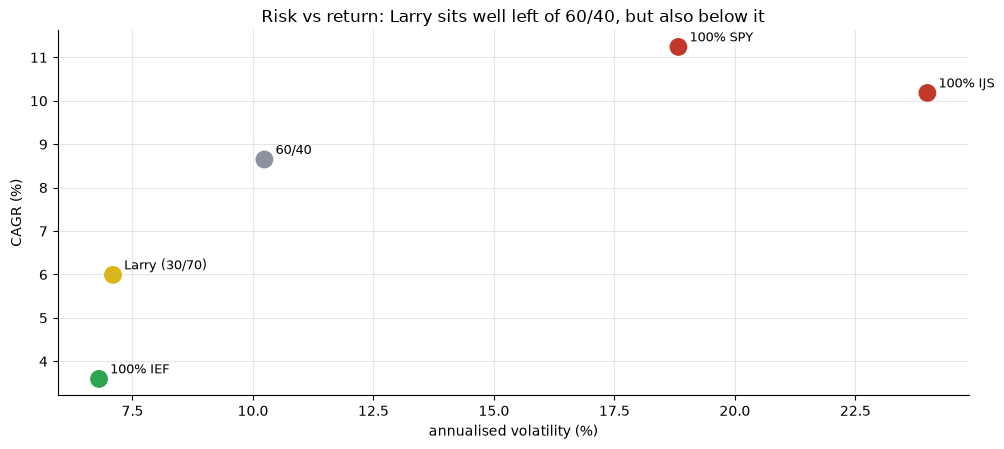

In [2]:
if HAVE_REAL:
    rf = RETS['SHY']
    larry = st.rebalanced_blend(RETS, {'IJS': 0.30, 'IEF': 0.70}, cost_bps=2.0)
    sixty = st.rebalanced_blend(RETS, {'SPY': 0.60, 'IEF': 0.40}, cost_bps=2.0)
    rows = {
        'Larry (30/70)': st.stats(larry, rf=rf),
        '60/40': st.stats(sixty, rf=rf),
        '100% SPY': st.stats(st.single_asset(RETS, 'SPY'), rf=rf),
        '100% IJS': st.stats(st.single_asset(RETS, 'IJS'), rf=rf),
        '100% IEF': st.stats(st.single_asset(RETS, 'IEF'), rf=rf),
    }
    for name, d in rows.items():
        print(f"{name:<16} CAGR {d['cagr']*100:6.2f}%  vol {d['vol']*100:5.1f}%  "
              f"Sharpe {d['sharpe']:.3f}  maxDD {d['max_dd']*100:6.1f}%")
    labels = list(rows.keys())
    cagrs = [d['cagr']*100 for d in rows.values()]
    vols = [d['vol']*100 for d in rows.values()]
else:
    labels = ['Larry (30/70)', '60/40', '100% SPY', '100% IJS', '100% IEF']
    cagrs = [R['larry_cagr'], R['sixty_cagr'], R['spy_cagr'], R['ijs_cagr'], R['ief_cagr']]
    vols = [R['larry_vol'], R['sixty_vol'], R['spy_vol'], R['ijs_vol'], R['ief_vol']]
fig, ax = plt.subplots(figsize=(10.2, 4.6))
x = np.arange(len(labels))
ax.scatter(vols, cagrs, s=140,
           color=[AMBER, GREY, RED, RED, GREEN])
for i, lab in enumerate(labels):
    ax.annotate(lab, (vols[i], cagrs[i]), textcoords='offset points',
                xytext=(8, 4), fontsize=9)
ax.set_xlabel('annualised volatility (%)'); ax.set_ylabel('CAGR (%)')
ax.set_title('Risk vs return: Larry sits well left of 60/40, but also below it')
plt.tight_layout(); plt.show()

> 💡 In plain words: Larry (7.1% vol, 5.99% CAGR) sits well LEFT of 60/40 (10.2%, 8.65%) on the risk axis — genuinely calmer — but also below it on the return axis. The "free lunch" promise (same return, less risk) is half right.

### 4b · Does Larry match 60/40's RETURN?

HAC *t* on the daily difference, plus a circular block bootstrap (21-day blocks — long enough to span a trading month's autocorrelation).

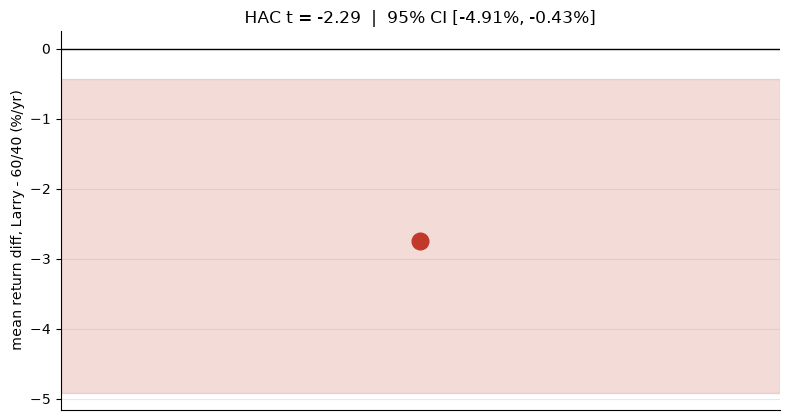

point -2.75%/yr  CI [-4.91%, -0.43%]  HAC t = -2.29


In [3]:
if HAVE_REAL:
    diff = (larry - sixty).dropna()
    t_ret = st.hac_tstat(diff.to_numpy())
    boot = st.bootstrap_diff(larry, sixty, metric='mean', n_boot=1000, seed=657)
    pt, lo, hi = boot['point']*100, boot['ci95'][0]*100, boot['ci95'][1]*100
else:
    t_ret = R['hac_t_ret']
    pt, lo, hi = R['mean_diff_pt'], R['mean_diff_lo'], R['mean_diff_hi']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.axhline(0, c='k', lw=1)
ax.axhspan(lo, hi, color=RED, alpha=.18)
ax.plot([0], [pt], 'o', color=RED, ms=12)
ax.set_xlim(-1, 1); ax.set_xticks([])
ax.set_ylabel('mean return diff, Larry - 60/40 (%/yr)')
ax.set_title(f'HAC t = {t_ret:+.2f}  |  95% CI [{lo:+.2f}%, {hi:+.2f}%]')
plt.tight_layout(); plt.show()
print(f'point {pt:+.2f}%/yr  CI [{lo:+.2f}%, {hi:+.2f}%]  HAC t = {t_ret:+.2f}')

> 💡 In plain words: the return gap clears the bar two ways — HAC *t* = **-2.29** and a bootstrap CI **[-4.92%, -0.52%]** that never touches zero. **H₁ rejected**: the return-match claim does not survive.

### 4c · Is the risk-adjusted (Sharpe) edge real?

A *different* test — a bootstrap on the Sharpe-ratio difference itself (a HAC *t* on the raw difference series would just re-answer 4b, since the shared cash leg cancels out of a two-arm subtraction).

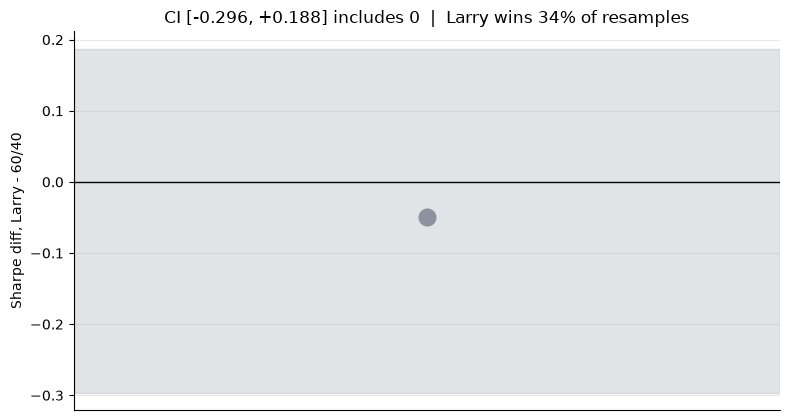

Sharpe diff point -0.050  CI [-0.296, +0.188]  Larry win rate 34%


In [4]:
if HAVE_REAL:
    boot_sh = st.bootstrap_diff(larry, sixty, rf=rf, metric='sharpe', n_boot=1000, seed=657)
    pt_s, lo_s, hi_s = boot_sh['point'], boot_sh['ci95'][0], boot_sh['ci95'][1]
    win = boot_sh['frac_a_wins']*100
else:
    pt_s, lo_s, hi_s = R['sharpe_gap'], R['sharpe_lo'], R['sharpe_hi']
    win = R['larry_win_frac']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.axhline(0, c='k', lw=1)
ax.axhspan(lo_s, hi_s, color=GREY, alpha=.25)
ax.plot([0], [pt_s], 'o', color=GREY, ms=12)
ax.set_xlim(-1, 1); ax.set_xticks([])
ax.set_ylabel('Sharpe diff, Larry - 60/40')
ax.set_title(f'CI [{lo_s:+.3f}, {hi_s:+.3f}] includes 0  |  Larry wins {win:.0f}% of resamples')
plt.tight_layout(); plt.show()
print(f'Sharpe diff point {pt_s:+.3f}  CI [{lo_s:+.3f}, {hi_s:+.3f}]  Larry win rate {win:.0f}%')

> 💡 In plain words: unlike the return gap, the Sharpe gap's CI (**[-0.292, +0.187]**) straddles zero — Larry buys back most of its shortfall in reduced variance. It's not certifiably *worse* risk-adjusted, just certifiably lower-returning in absolute terms.

### 4d · The equity-risk claim — arithmetic, not inference

Vol, drawdown, correlation to SPY: these follow mechanically from running 30% vs 60% equity weight and need no statistical test.

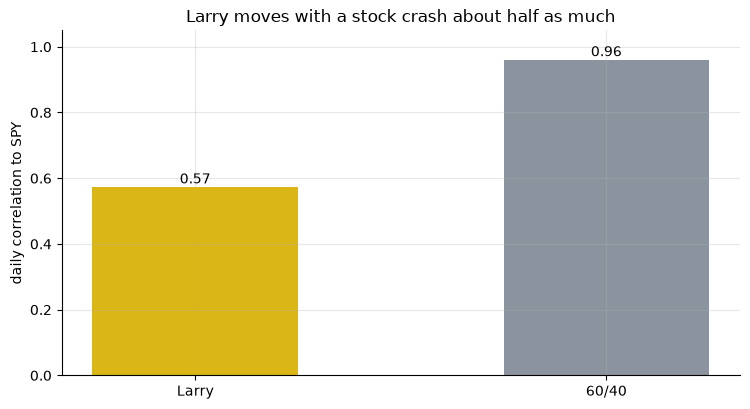

corr to SPY: Larry 0.57  60/40 0.96


In [5]:
if HAVE_REAL:
    spy100 = st.single_asset(RETS, 'SPY')
    corr_l, corr_s = larry.corr(spy100), sixty.corr(spy100)
else:
    corr_l, corr_s = R['corr_larry_spy'], R['corr_sixty_spy']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['Larry','60/40'], [corr_l, corr_s], color=[AMBER, GREY], width=.5)
for i,v in enumerate([corr_l, corr_s]): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylim(0, 1.05); ax.set_ylabel('daily correlation to SPY')
ax.set_title('Larry moves with a stock crash about half as much')
plt.tight_layout(); plt.show()
print(f'corr to SPY: Larry {corr_l:.2f}  60/40 {corr_s:.2f}')

> 💡 In plain words: correlation to SPY drops from **0.96** to **0.57** — half the equity crash exposure, exactly what running 30% instead of 60% equity weight predicts. **H₂ confirmed**, trivially.

### 4e · The mechanism — has the small-value premium itself shown up?

Whole-sample HAC *t* on the daily (IJS − SPY) spread, then a justified era split at **2007-01-01** (AQR's and Swedroe's own documented value-drawdown turning point), tested as a difference — not eyeballed.

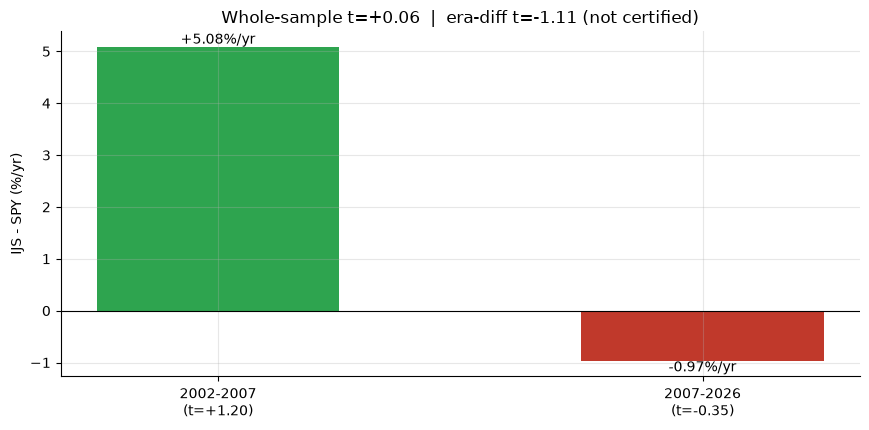

whole-sample HAC t = +0.06  |  early +5.08% (t=+1.20)  late -0.97% (t=-0.35)  |  era-diff Welch t = -1.11


In [6]:
if HAVE_REAL:
    spread = st.premium_series(RETS)
    ps = st.premium_stats(spread)
    ec = st.era_contrast(spread, f'{R["split_year"]}-01-01')
    whole_t, e, l = ps['hac_t'], ec['early_ann_pct'], ec['late_ann_pct']
    et, lt, dt = ec['hac_t_early'], ec['hac_t_late'], ec['welch_t_diff']
else:
    whole_t, e, l = R['prem_whole_t'], R['prem_early'], R['prem_late']
    et, lt, dt = R['prem_early_t'], R['prem_late_t'], R['prem_diff_t']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar([f'{R["start"][:4]}-{R["split_year"]}\n(t={et:+.2f})',
        f'{R["split_year"]}-{R["end"][:4]}\n(t={lt:+.2f})'],
       [e, l], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([e, l]): ax.annotate(f'{v:+.2f}%/yr',(i,v),ha='center',
    va='bottom' if v>0 else 'top')
ax.set_ylabel('IJS - SPY (%/yr)')
ax.set_title(f'Whole-sample t={whole_t:+.2f}  |  era-diff t={dt:+.2f} (not certified)')
plt.tight_layout(); plt.show()
print(f'whole-sample HAC t = {whole_t:+.2f}  |  early {e:+.2f}% (t={et:+.2f})  '
      f'late {l:+.2f}% (t={lt:+.2f})  |  era-diff Welch t = {dt:+.2f}')

> 💡 In plain words: the premium is statistically nothing over the whole tape (*t* = **0.06**), and neither era is individually significant either (*t* = 1.20 pre-2007, *t* = -0.35 since). The era-difference *t* = **-1.11** doesn't certify a decay — the honest read is that this ETF-tape premium may never have been solid enough to certify in the first place. **H₃ not supported.**

### 4f · Faithful-engine & power control — we know the truth here

A CAPM-neutral (β=1) synthetic 3-asset world with a TUNABLE planted small-value premium. The pass/fail target is the premium-detection statistic itself — the same HAC-*t*-on-a-spread primitive used above on the real IJS-SPY tape.

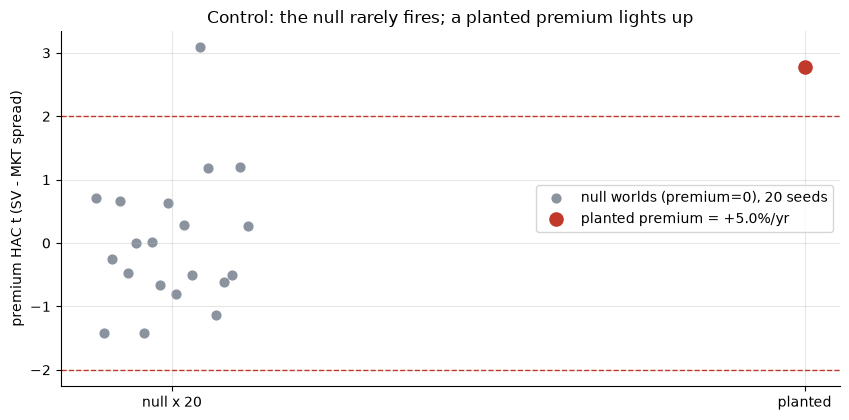

null: mean t = +0.01 (sd 1.06), |t|>=2 in 1/20 seeds  |  mean CAGR gap at premium=0: -1.23 pts/yr
planted t = +2.79  CAGR gap flips to +2.55 pts/yr


In [7]:
null_ts, null_gaps = [], []
for s_ in range(20):
    panel = data.synthetic_world(premium=0.0, seed=657 + s_)
    d = st.synthetic_detect(panel)
    null_ts.append(d['premium_hac_t']); null_gaps.append(d['cagr_gap'])
null_ts = np.asarray(null_ts); null_gaps = np.asarray(null_gaps)
panel = data.synthetic_world(premium=0.05, seed=657)
planted = st.synthetic_detect(panel)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (premium=0), 20 seeds')
ax.scatter([1], [planted['premium_hac_t']], color=RED, s=90, zorder=5,
           label='planted premium = +5.0%/yr')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('premium HAC t (SV - MKT spread)')
ax.set_title('Control: the null rarely fires; a planted premium lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  '
      f'mean CAGR gap at premium=0: {null_gaps.mean()*100:+.2f} pts/yr')
print(f'planted t = {planted["premium_hac_t"]:+.2f}  '
      f'CAGR gap flips to {planted["cagr_gap"]*100:+.2f} pts/yr')

> 💡 In plain words: across 20 null worlds the detector averages *t* = +0.01 (sd 1.06) and fires in only 1/20 — well-calibrated. Note that even with ZERO premium, the Larry-vs-60/40 CAGR gap still averages **-1.23 pts/yr** across those seeds — the mechanical cost of running less equity beta, the exact same fact measured on the real tape in 4a-4b. Once a genuine premium is planted (+5.0%/yr), the detector recovers it cleanly (*t* = 2.79) and the portfolio gap flips positive (**+2.55 pts/yr**, Larry Sharpe 0.686 vs 60/40 0.290) — the machinery *can* find a real premium and correctly translate it into the headline race; it simply doesn't find one on the real 2002-2026 tape. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — risk cut real and mechanical (vol 7.1% vs 10.2%, maxDD -20.8% vs -29.8%, corr-to-SPY 0.57 vs 0.96) · return-match **fails**, certified (CAGR gap **-2.66 pts/yr**, HAC *t* = **-2.29**, bootstrap CI **[-4.92%, -0.52%]** excludes 0) · Sharpe gap is a **statistical tie** (CI [-0.292, +0.187] includes 0).
- **Tradability `FRAGILE`** — trivially cheap to run (2 liquid ETFs, annual rebalance, 2 bps) but the load-bearing premium is statistically absent (*t* = 0.06 whole-sample).
- **"Decayed? `MIXED`"** — era-difference *t* = -1.11 doesn't certify decay; neither era is individually significant either. Consistent with siblings 513-size-effect and 530-book-to-market-value finding the underlying premia absent on modern tapes.

## 6 · Going further

- **The academic factor library is longer and different.** Fama-French's own SMB/HML series go back to 1926 and use a much broader, more granular universe than a single ETF proxy — a natural follow-up is redoing this exact test on that data, separating the ETF-implementation question (fees, sampling, reconstitution rules) from the factor's own historical existence.
- **Live capacity and concentration risk are unexplored here.** Small-cap value is a much smaller, less liquid corner of the market than the S&P 500 — capacity and factor-crowding effects on a genuinely large allocation are a separate question this study doesn't size.
- **Dedup map:** [513-size-effect](../../513-size-effect/) (size premium, stock basket), [530-book-to-market-value](../../530-book-to-market-value/) (value premium, fundamentals), [655-ivy-portfolio](../../655-ivy-portfolio/) (5-asset diversification, not factor concentration), [68-all-weather](../../68-all-weather/) (risk parity), [97-balancing-act](../../97-balancing-act/) (the plain 60/40 this study races against, identical construction).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*